In [112]:
pip install ucimlrepo

In [113]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
letter_recognition = fetch_ucirepo(id=59)

# data (as pandas dataframes)
X = letter_recognition.data.features
y = letter_recognition.data.targets

# metadata
print(letter_recognition.metadata)

# variable information
print(letter_recognition.variables)


{'uci_id': 59, 'name': 'Letter Recognition', 'repository_url': 'https://archive.ics.uci.edu/dataset/59/letter+recognition', 'data_url': 'https://archive.ics.uci.edu/static/public/59/data.csv', 'abstract': 'Database of character image features; try to identify the letter', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 20000, 'num_features': 16, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['lettr'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1991, 'last_updated': 'Thu Sep 28 2023', 'dataset_doi': '10.24432/C5ZP40', 'creators': ['David Slate'], 'intro_paper': None, 'additional_info': {'summary': 'The objective is to identify each of a large number of black-and-white rectangular pixel displays as one of the 26 capital letters in the English alphabet.  The character images were based on 20 different fonts and each letter within these 20 fonts wa

In [114]:
X.head()

,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
0,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [115]:
y.head()

,lettr
0,T
1,I
2,D
3,N
4,G


In [116]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score

In [117]:
X.info()
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   x-box   20000 non-null  int64
 1   y-box   20000 non-null  int64
 2   width   20000 non-null  int64
 3   high    20000 non-null  int64
 4   onpix   20000 non-null  int64
 5   x-bar   20000 non-null  int64
 6   y-bar   20000 non-null  int64
 7   x2bar   20000 non-null  int64
 8   y2bar   20000 non-null  int64
 9   xybar   20000 non-null  int64
 10  x2ybr   20000 non-null  int64
 11  xy2br   20000 non-null  int64
 12  x-ege   20000 non-null  int64
 13  xegvy   20000 non-null  int64
 14  y-ege   20000 non-null  int64
 15  yegvx   20000 non-null  int64
dtypes: int64(16)
memory usage: 2.4 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   lettr   20000 non-null  object
dtypes

In [118]:
X.rename(columns = {'yegvx':'yegevx', 'xegvy': 'xegevy'}, inplace = True)

<ipython-input-118-2365c1e8172d>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [119]:
X.isnull().sum()/len(X)*100

,0
x-box,0.0
y-box,0.0
width,0.0
high,0.0
onpix,0.0
x-bar,0.0
y-bar,0.0
x2bar,0.0
y2bar,0.0
xybar,0.0


We can see there is are no null values in the dataset so there is no need of null value correction

In [120]:
df = pd.concat([X, y], axis=1)

In [121]:
df.head()

,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegevy,y-ege,yegevx,lettr
0,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8,T
1,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10,I
2,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9,D
3,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8,N
4,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10,G


In [122]:
from sklearn.preprocessing import MinMaxScaler

from sklearn.preprocessing import MinMaxScaler

columns_to_normalize = ["x-box", "y-box", "width", "high", "onpix", "x-bar", "y-bar", "x2bar", "y2bar", "xybar", "x2ybr", "xy2br", "x-ege", "xegevy", "y-ege", "yegevx"]


scaler = MinMaxScaler()
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

df.head()


,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegevy,y-ege,yegevx,lettr
0,0.133333,0.533333,0.2,0.333333,0.066667,0.533333,0.866667,0.000000,0.400000,0.400000,0.666667,0.533333,0.000000,0.533333,0.000000,0.533333,T
1,0.333333,0.800000,0.2,0.466667,0.133333,0.666667,0.333333,0.333333,0.266667,0.866667,0.200000,0.600000,0.133333,0.533333,0.266667,0.666667,I
2,0.266667,0.733333,0.4,0.533333,0.400000,0.666667,0.400000,0.133333,0.400000,0.666667,0.200000,0.466667,0.200000,0.466667,0.200000,0.600000,D
3,0.466667,0.733333,0.4,0.400000,0.200000,0.333333,0.600000,0.266667,0.400000,0.266667,0.266667,0.666667,0.400000,0.666667,0.133333,0.533333,N
4,0.133333,0.066667,0.2,0.066667,0.066667,0.533333,0.400000,0.400000,0.400000,0.400000,0.333333,0.600000,0.066667,0.466667,0.333333,0.666667,G


In [123]:
df["lettr"].unique()

array(['T', 'I', 'D', 'N', 'G', 'S', 'B', 'A', 'J', 'M', 'X', 'O', 'R',
       'F', 'C', 'H', 'W', 'L', 'P', 'E', 'V', 'Y', 'Q', 'U', 'K', 'Z'],
      dtype=object)

In [124]:
df['lettr']= df['lettr'].map({
    'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8,
    'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16,
    'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24,
    'Z': 25
})


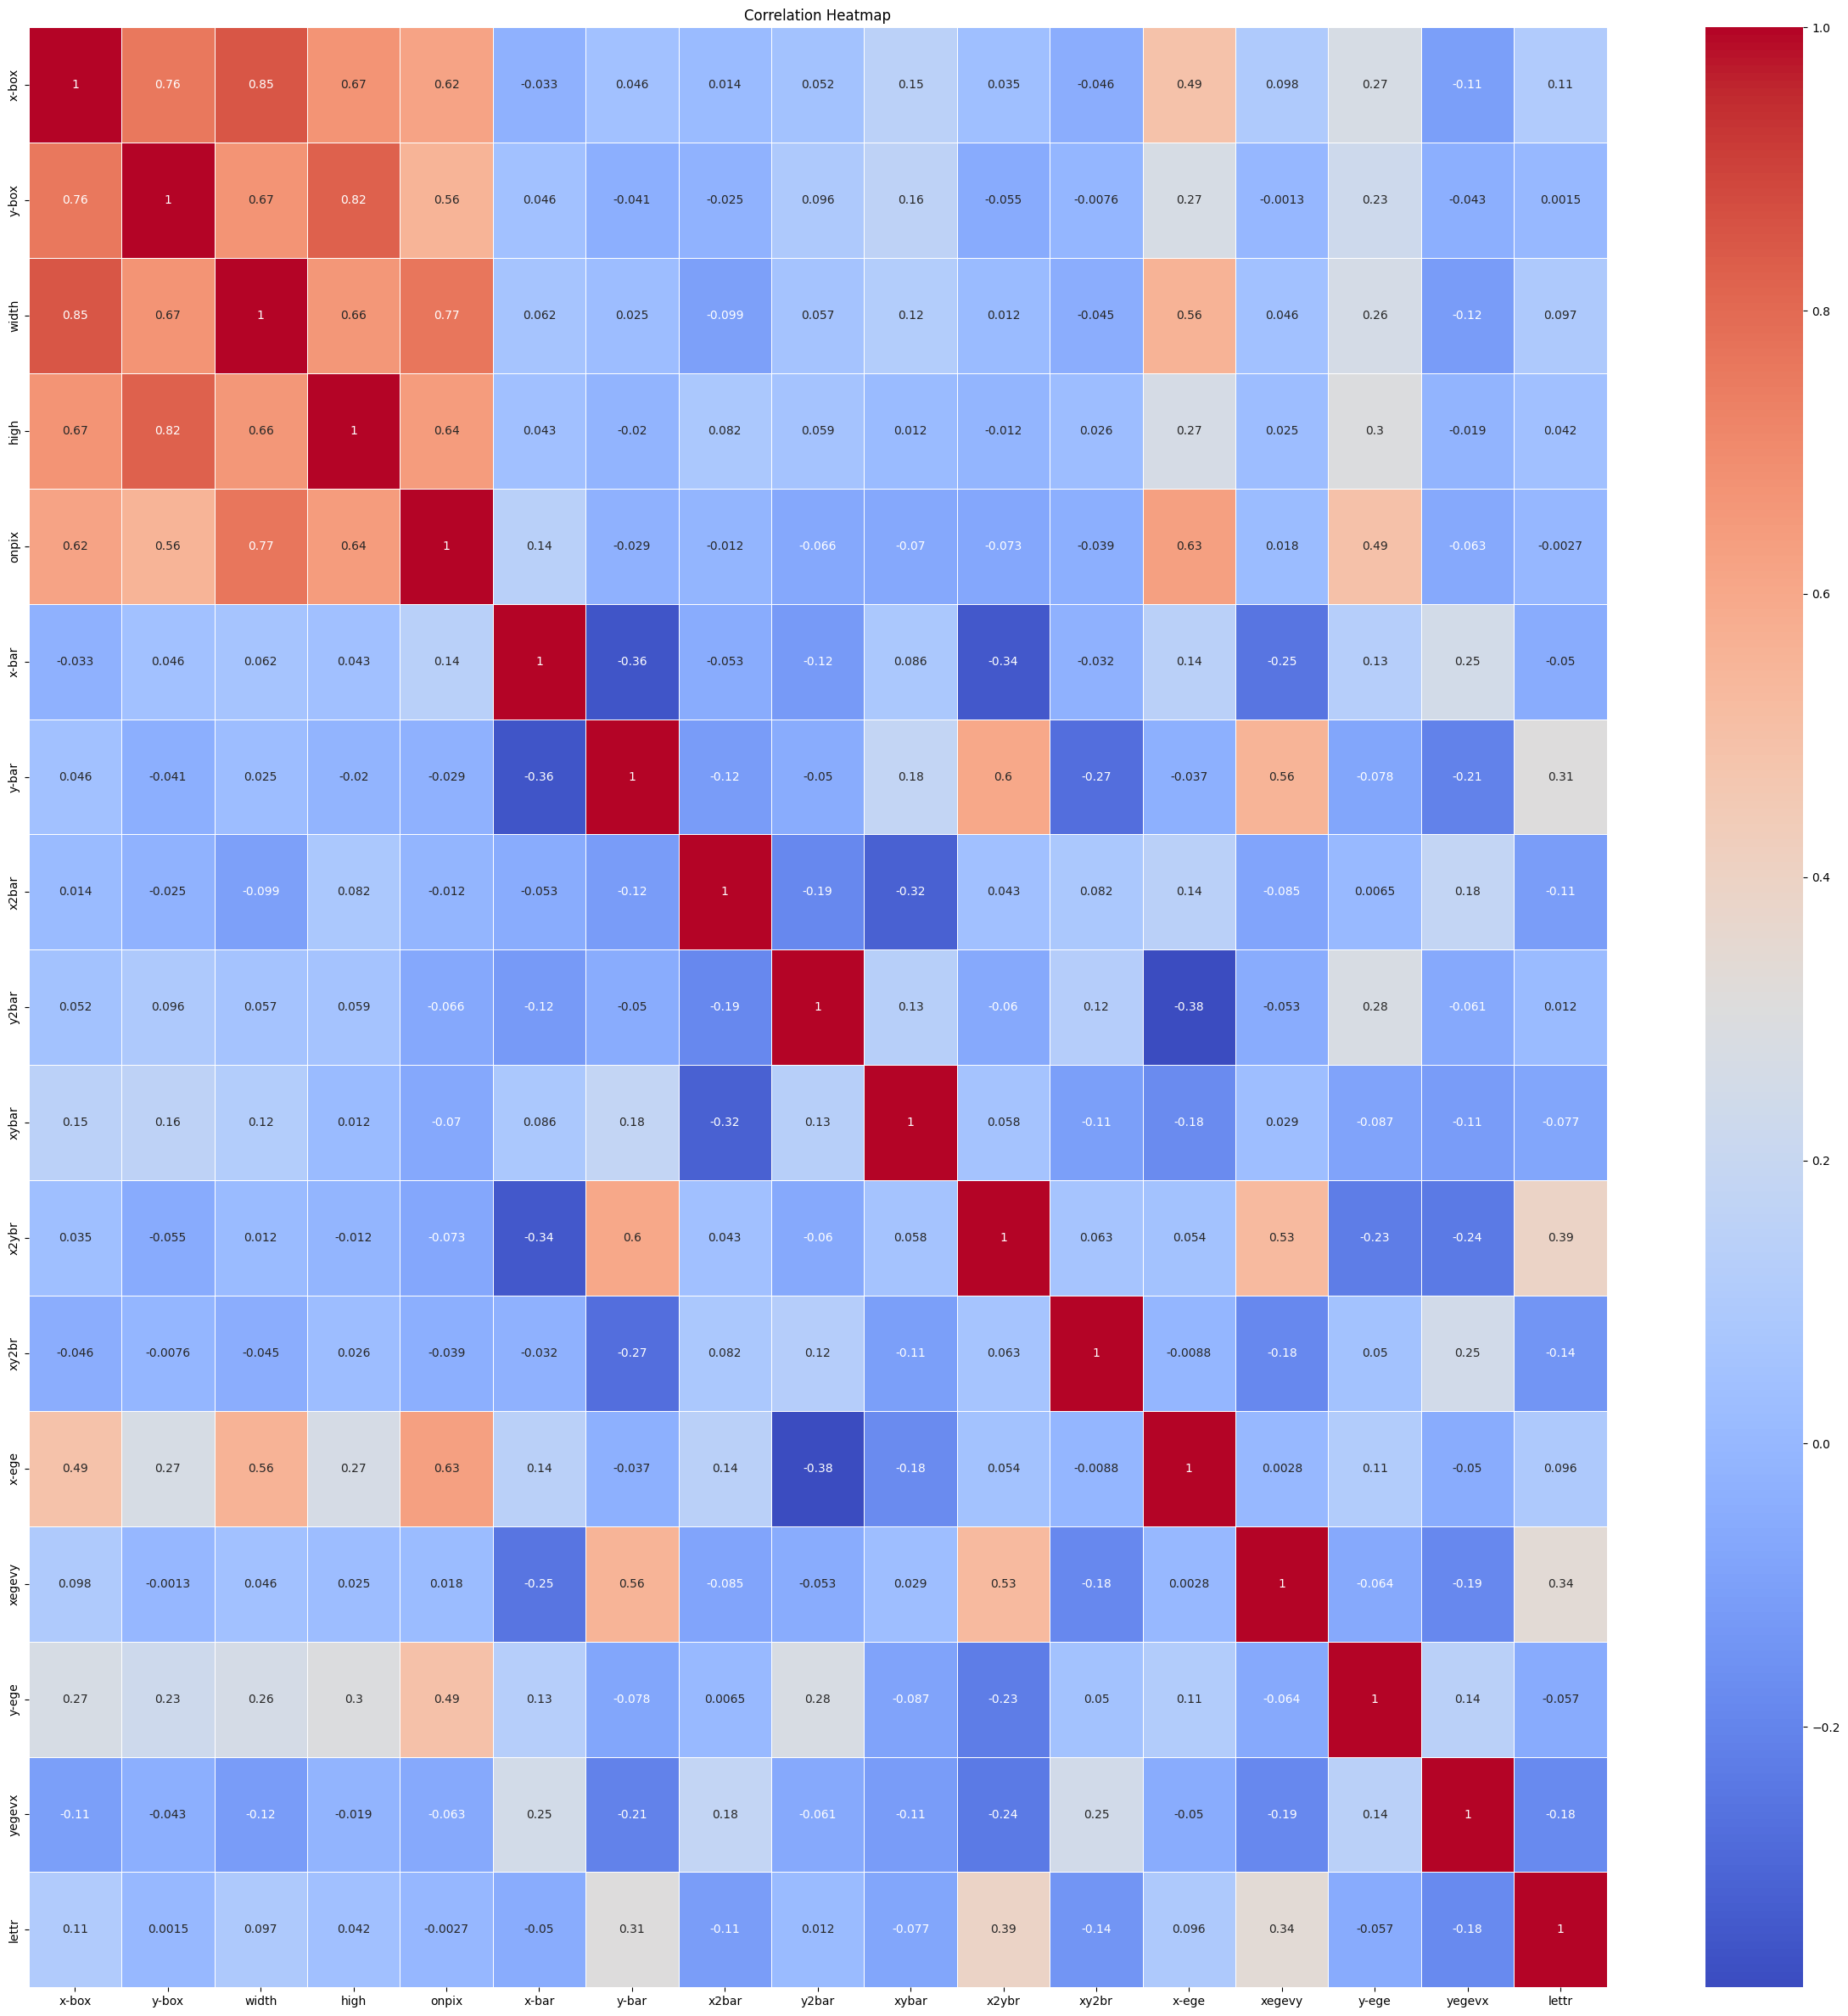

In [125]:
plt.figure(figsize=(30, 30))
sns.heatmap(df.corr() , annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [126]:
new_data = df.copy()
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x-box   20000 non-null  float64
 1   y-box   20000 non-null  float64
 2   width   20000 non-null  float64
 3   high    20000 non-null  float64
 4   onpix   20000 non-null  float64
 5   x-bar   20000 non-null  float64
 6   y-bar   20000 non-null  float64
 7   x2bar   20000 non-null  float64
 8   y2bar   20000 non-null  float64
 9   xybar   20000 non-null  float64
 10  x2ybr   20000 non-null  float64
 11  xy2br   20000 non-null  float64
 12  x-ege   20000 non-null  float64
 13  xegevy  20000 non-null  float64
 14  y-ege   20000 non-null  float64
 15  yegevx  20000 non-null  float64
 16  lettr   20000 non-null  int64  
dtypes: float64(16), int64(1)
memory usage: 2.6 MB


In [127]:
print(new_data[new_data['lettr'] == 0])
print(new_data[new_data['lettr'] == 25])


          x-box     y-box     width      high     onpix     x-bar     y-bar  \
7      0.066667  0.066667  0.200000  0.133333  0.066667  0.533333  0.133333   
78     0.200000  0.466667  0.333333  0.333333  0.200000  0.800000  0.133333   
118    0.200000  0.533333  0.333333  0.400000  0.200000  0.600000  0.133333   
130    0.133333  0.066667  0.266667  0.133333  0.066667  0.533333  0.066667   
134    0.200000  0.466667  0.333333  0.333333  0.200000  0.666667  0.266667   
...         ...       ...       ...       ...       ...       ...       ...   
19893  0.200000  0.466667  0.266667  0.333333  0.133333  0.466667  0.266667   
19951  0.400000  0.666667  0.466667  0.400000  0.200000  0.800000  0.000000   
19966  0.133333  0.200000  0.200000  0.066667  0.066667  0.400000  0.133333   
19977  0.200000  0.600000  0.333333  0.400000  0.133333  0.400000  0.333333   
19999  0.266667  0.600000  0.400000  0.400000  0.133333  0.600000  0.333333   

          x2bar     y2bar     xybar     x2ybr     x

In [128]:
print(new_data['lettr'].unique())


[19  8  3 13  6 18  1  0  9 12 23 14 17  5  2  7 22 11 15  4 21 24 16 20
 10 25]


In [129]:
from scipy.stats import ttest_ind, f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hypothesis Testing
# Compare the mean of on pixels for letter A and Z
meeanA = new_data[new_data['lettr'] == 0]['x-bar']
meeanZ = new_data[new_data['lettr'] == 25]['x-bar']

t_stat, p_value = ttest_ind(meeanA, meeanZ)
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 15.87391903324838
P-value: 1.2662626721382123e-52


In [130]:
from scipy.stats import chi2_contingency

# Chi-Square Test
# Conduct a Chi-Square test on the feature 'xybar' and the target variable 'lettr'
gender_target_crosstab = pd.crosstab(new_data['xybar'], new_data['lettr'])
chi2_stat, p_value_chi2, dof, expected = chi2_contingency(gender_target_crosstab)

print("Chi-Square Statistic:", chi2_stat)
print("P-value (Chi-Square):", p_value_chi2)

# Interpretation of Chi-Square Test
if p_value_chi2 < 0.05:
    print("There is a significant association between correlation of x & y and lettr.")
else:
    print("There is no significant association between correlation of x & y and Target.")


Chi-Square Statistic: 26889.414326908416
P-value (Chi-Square): 0.0
There is a significant association between correlation of x & y and lettr.


In [131]:
gender_target_crosstab = pd.crosstab(new_data['onpix'], new_data['lettr'])
chi2_stat, p_value_chi2, dof, expected = chi2_contingency(gender_target_crosstab)

print("Chi-Square Statistic:", chi2_stat)
print("P-value (Chi-Square):", p_value_chi2)

# Interpretation of Chi-Square Test
if p_value_chi2 < 0.05:
    print("There is a significant association between number of on pixels and Target.")
else:
    print("There is no significant association between number of on pixels and Target.")

Chi-Square Statistic: 4723.2162847148775
P-value (Chi-Square): 0.0
There is a significant association between number of on pixels and Target.


Through the heatmap and above inferences we can draw out the conclsion to take dependent and assosiated features to refine our data for prediction modelling

In [132]:
import pandas as pd
import plotly.express as px

# Step 1: Count occurrences of each letter (mapped as numerical values in `lettr` column)
x = new_data['lettr'].value_counts().index  # Unique letters (numerical indices)
y = new_data['lettr'].value_counts().values  # Count of each letter

# Step 2: Create a DataFrame for plotting
df = pd.DataFrame({
    'Letter': [chr(i + 65) for i in x],  # Convert numerical indices back to letters
    'Count': y
})

# Step 3: Plot a pie chart
fig = px.pie(df,
             names='Letter',
             values='Count',
             title='Distribution of Letters in Dataset')

# Step 4: Customize the pie chart
fig.update_traces(
    hole=0.4,  # Create a donut chart
    textinfo='value+label',  # Show value and label
    pull=[0.1 if count == max(y) else 0 for count in y]  # Highlight the most frequent letter
)

# Step 5: Show the chart
fig.show()


In [133]:
# Regression Analysis
# Example: Linear regression to predict 'lettr based on 'mean x y correlation' and 'total # on pixels'
model = ols('lettr ~ xybar + Q("onpix")', data=new_data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA Table:\n", anova_table)

ANOVA Table:
                   sum_sq       df           F        PR(>F)
xybar       6.791793e+03      1.0  121.394256  3.774900e-28
Q("onpix")  7.346750e+01      1.0    1.313134  2.518418e-01
Residual    1.118797e+06  19997.0         NaN           NaN


Index(['lettr', 'x2ybr', 'xegevy', 'y-bar', 'yegevx', 'xy2br', 'x2bar',
       'x-box', 'width', 'x-ege'],
      dtype='object')


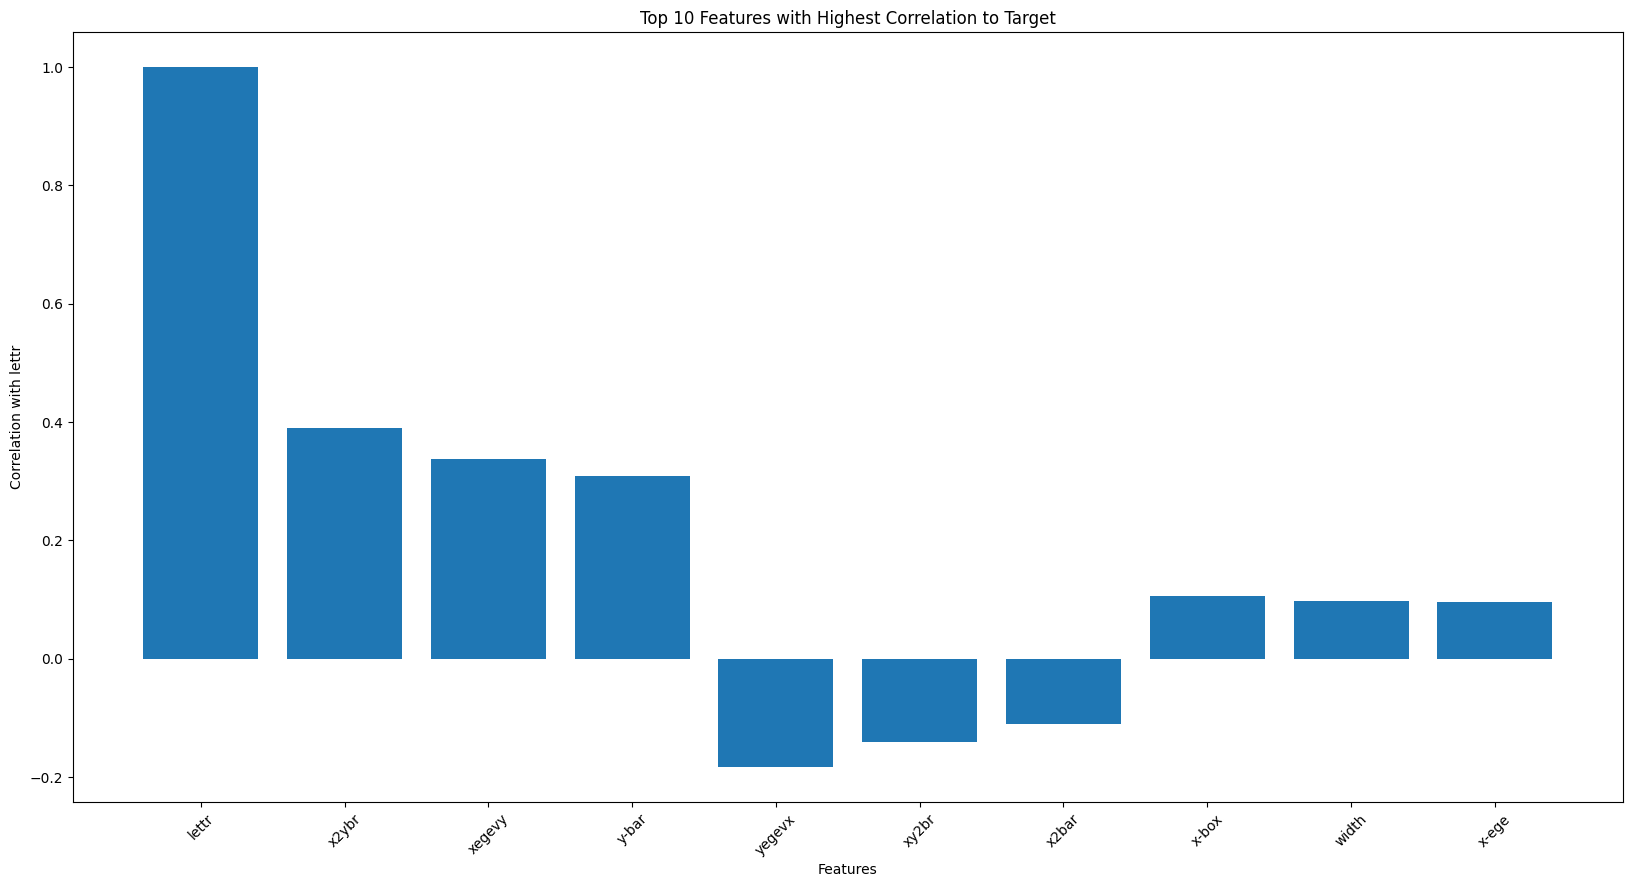

In [134]:
correlations = new_data.corr()['lettr']
top_10_features = correlations.abs().nlargest(10).index
top_10_corr_values = correlations[top_10_features]
print(top_10_features)
plt.figure(figsize=(20, 10))
plt.bar(top_10_features, top_10_corr_values)
plt.xlabel('Features')
plt.ylabel('Correlation with lettr')
plt.title('Top 10 Features with Highest Correlation to Target')
plt.xticks(rotation=45)
plt.show()

In [135]:
fig = px.scatter(new_data,
             x = 'xegevy',
             y = 'yegevx',
             color = 'lettr')
fig.show()

In [136]:
fig = px.scatter(new_data,
             x = 'x-ege',
             y = 'y-ege',
             color = 'lettr')
fig.show()

In [137]:
fig = px.box(new_data, y='onpix')
fig.show()

<Axes: xlabel='onpix', ylabel='Count'>

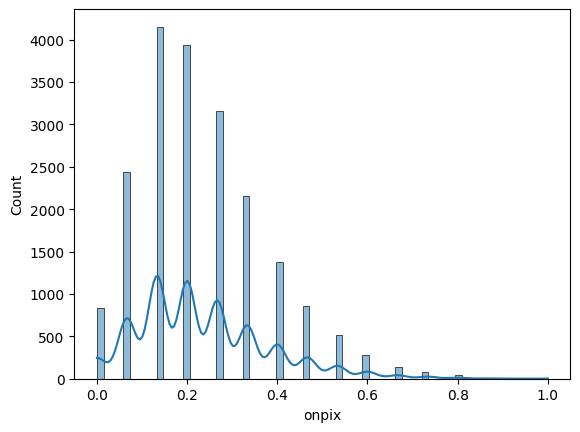

In [138]:
# Distribution of lettrs of students based on total number of on pixels
sns.histplot(data=new_data['onpix'], kde=True)

In [139]:
# Let's try plotly histogram for interactive figure
px.histogram(new_data['onpix'], x='onpix',color_discrete_sequence=['lightpink'])

In [144]:
# ANOVA : Compare the mean width across different 'letters'
letter_levels = new_data['lettr'].unique()

# Create subgroups based on 'lettr'
letter_groups = [new_data[new_data['lettr'] == level]['width'] for level in letter_levels]
f_stat, p_value_anova = f_oneway(*letter_groups)
print("F-statistic (ANOVA):", f_stat)
print("P-value (ANOVA):", p_value_anova)

F-statistic (ANOVA): 129.61413458923226
P-value (ANOVA): 0.0


In [145]:
X = new_data.iloc[:,0:13]
y = new_data.iloc[:,-1]
X

,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege
0,0.133333,0.533333,0.200000,0.333333,0.066667,0.533333,0.866667,0.000000,0.400000,0.400000,0.666667,0.533333,0.000000
1,0.333333,0.800000,0.200000,0.466667,0.133333,0.666667,0.333333,0.333333,0.266667,0.866667,0.200000,0.600000,0.133333
2,0.266667,0.733333,0.400000,0.533333,0.400000,0.666667,0.400000,0.133333,0.400000,0.666667,0.200000,0.466667,0.200000
3,0.466667,0.733333,0.400000,0.400000,0.200000,0.333333,0.600000,0.266667,0.400000,0.266667,0.266667,0.666667,0.400000
4,0.133333,0.066667,0.200000,0.066667,0.066667,0.533333,0.400000,0.400000,0.400000,0.400000,0.333333,0.600000,0.066667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,0.133333,0.133333,0.200000,0.200000,0.133333,0.466667,0.466667,0.466667,0.400000,0.400000,0.400000,0.266667,0.133333
19996,0.466667,0.666667,0.533333,0.533333,0.266667,0.266667,0.533333,0.400000,0.600000,0.800000,0.600000,0.866667,0.133333
19997,0.400000,0.600000,0.400000,0.466667,0.333333,0.400000,0.733333,0.200000,0.466667,0.733333,0.600000,0.333333,0.133333
19998,0.133333,0.200000,0.266667,0.133333,0.066667,0.533333,0.466667,0.133333,0.400000,0.666667,0.400000,0.533333,0.066667


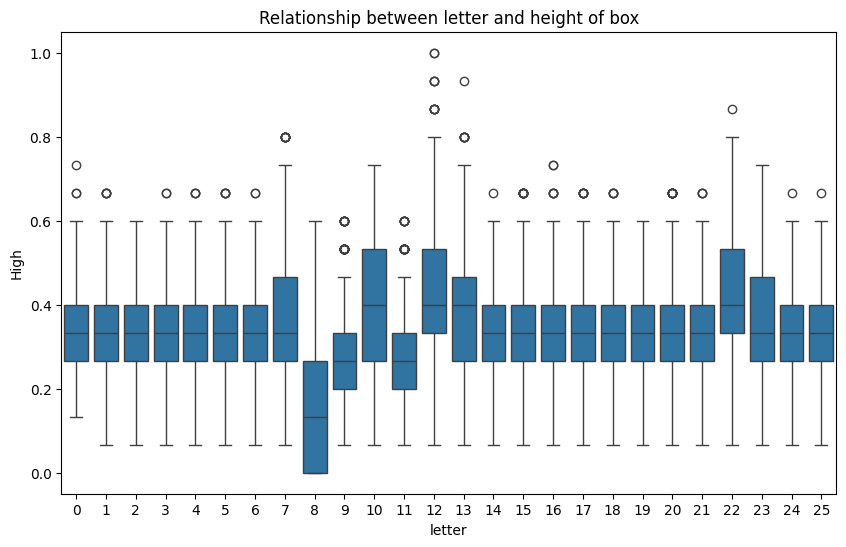

In [147]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='lettr', y='width', data=new_data)
plt.xlabel('letter')
plt.ylabel('Width')
plt.title('Relationship between letter and width of box')
plt.show()